<a href="https://www.kaggle.com/code/eaganrainmahasin/pra-pemrosesan-citra?scriptVersionId=349664819" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
#Instalasi Libray

import cv2
import numpy as np
import matplotlib.pyplot as plt

========== Deskripsi Gambar ==========
Shape: (1024, 1024)
Min: 0
Max: 255
Mean: 135.70952701568604
Unique: 256
Tipe data: uint8
Jumlah nilai piksel: 256
Nilai piksel: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

 ========== Gambarnya ==========


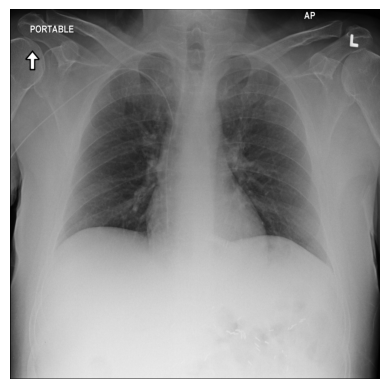

In [2]:
# Load dataset

img = cv2.imread('/kaggle/input/datasets/nih-chest-xrays/sample/sample/sample/images/00000246_003.png', 0)
print("="*10, "Deskripsi Gambar", "="*10)
print("Shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())
print("Mean:", img.mean())
print("Unique:", len(np.unique(img)))
print("Tipe data:", img.dtype)

unique_values = np.unique(img)
print("Jumlah nilai piksel:", len(unique_values))
print("Nilai piksel:", unique_values[:20])

print("\n","="*10, "Gambarnya", "="*10)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

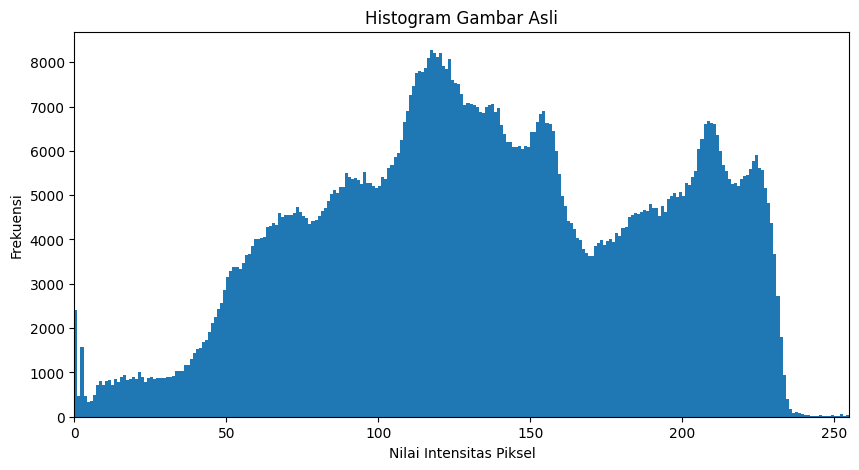

In [3]:
plt.figure(figsize=(10, 5))

plt.hist(img.ravel(), bins=256, range=(0, 256))

plt.title("Histogram Gambar Asli")
plt.xlabel("Nilai Intensitas Piksel")
plt.ylabel("Frekuensi")
plt.xlim(0, 255)

plt.show()

In [4]:
# Resized Image
h, w = img.shape[:2]

scale = 224 / max(h, w)

new_w = int(w * scale)
new_h = int(h * scale)

img_resized = cv2.resize(img, (new_w, new_h))
print("="*10, "Perbandingan Gambar", "="*10)
print("Hasil sebelum resize:", img.shape)
print("Hasil setelah resise:", img_resized.shape)
print("Mean:", img_resized.mean())
print("Std :", img_resized.std())

========== Perbandingan Gambar ==========
Hasil sebelum resize: (1024, 1024)
Hasil setelah resise: (224, 224)
Mean: 135.87009725765307
Std : 54.609297455480075


In [5]:
# Normalisasi Min-max [0, 1]

norm = cv2.normalize(
    img_resized, 
    None, 
    0, 
    1, 
    cv2.NORM_MINMAX, 
    dtype=cv2.CV_32F
)
print("="*10, "Perbandingan Gambar", "="*10)
print("Min sebelum normalisasi:", img.min())
print("Min sesudah normalisasi:", norm.min())
print("Max sebelum normalisasi:", img.max())
print("Max sesudah normalisasi:", norm.max())

========== Perbandingan Gambar ==========
Min sebelum normalisasi: 0
Min sesudah normalisasi: 0.0
Max sebelum normalisasi: 255
Max sesudah normalisasi: 1.0


In [6]:
# Noise Removal (Median Filter)

denoise_median = cv2.medianBlur((norm*255).astype(np.uint8), 3)
denoise_normal = cv2.blur((norm*255).astype(np.uint8), (3, 3))
denoise_gaussian = cv2.GaussianBlur((norm*255).astype(np.uint8), (3, 3), 0)
denoise_bilateral = cv2.bilateralFilter((norm*255).astype(np.uint8), 9, 75, 75)

print("="*10, "Perbandingan Statistik", "="*10)
print("="*5, "Denoise Median")
print("Mean:", denoise_median.mean())
print("Std :", denoise_median.std())
print("="*5, "Denoise Normal")
print("Mean:", denoise_normal.mean())
print("Std :", denoise_normal.std())
print("="*5, "Denoise Gaussian")
print("Mean:", denoise_gaussian.mean())
print("Std :", denoise_gaussian.std())
print("="*5, "Denoise Billateral")
print("Mean:", denoise_bilateral.mean())
print("Std :", denoise_bilateral.std())

========== Perbandingan Statistik ==========
===== Denoise Median
Mean: 135.68712133290816
Std : 54.44086314227253
===== Denoise Normal
Mean: 135.90884088010205
Std : 54.01530820398975
===== Denoise Gaussian
Mean: 135.9307238520408
Std : 54.08870413000559
===== Denoise Billateral
Mean: 135.91177056760205
Std : 53.66640361008909


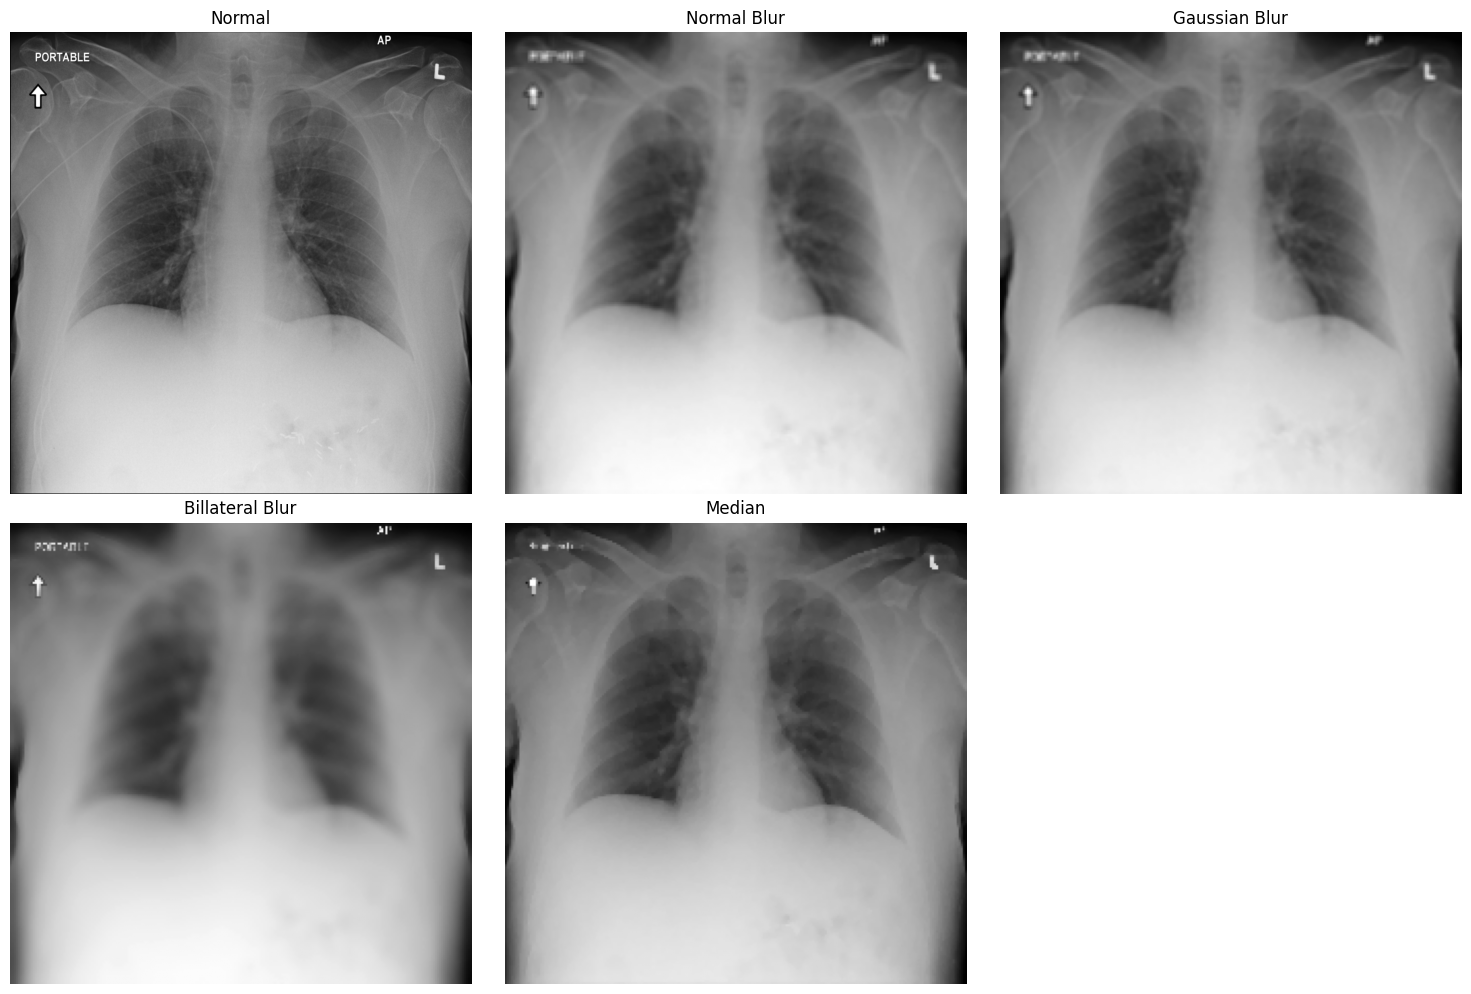

In [7]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Normal")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(denoise_median, cmap='gray')
plt.title("Median")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(denoise_normal, cmap='gray')
plt.title("Normal Blur")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(denoise_gaussian, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(denoise_bilateral, cmap='gray')
plt.title("Billateral Blur")
plt.axis('off')

plt.tight_layout()
plt.show()

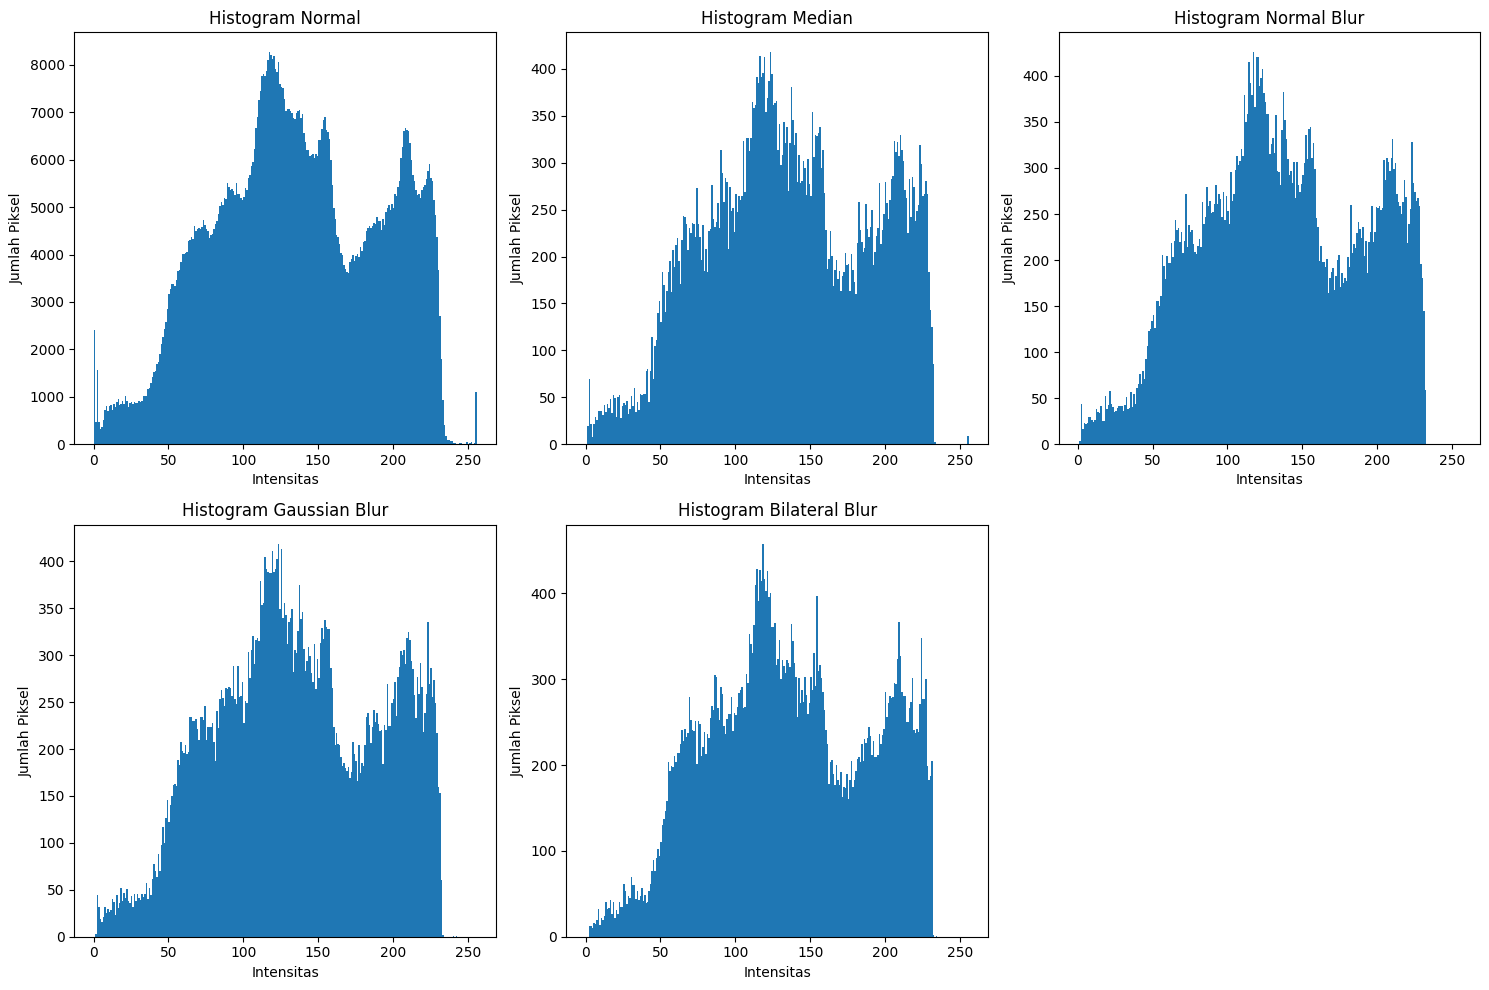

In [8]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Normal")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 3, 2)
plt.hist(denoise_median.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Median")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 3, 3)
plt.hist(denoise_normal.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Normal Blur")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 3, 4)
plt.hist(denoise_gaussian.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Gaussian Blur")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 3, 5)
plt.hist(denoise_bilateral.ravel(), bins=256, range=(0, 256))
plt.title("Histogram Bilateral Blur")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()